# Lab 12

Description of lab:

Know the challenges of giving causal interpretation to regression results of observational data. Know several techniques that can be use to try to give causal interpretation to regression models of observational data.

In [3]:
# Importing packages and preferences
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.facecolor'] ="white"
plt.rcParams['grid.color'] ="grey"
plt.rcParams['grid.linestyle'] = "dotted"
plt.rcParams["axes.labelsize"]= 14
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="white"
plt.rcParams["figure.figsize"] = [15,8]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']

pd.set_option('display.max_columns', None)

### The fundamental problem of causal inference

When estimating causal inference, there is an issue known as the **fundamental problem of causal inference**. This refers to the idea that to truly be able to estimate a causal effect, you need information on an inherently unobservable **counterfactual**. As an example, if you want to estimate the effect of education on future earnings, we would ideally want to compare a situation where an individual both recieves an education and does not recieve an education, this is of course impossible. Instead we have to compare people who have an education with those who do not, when doing this all sorts of problems pop up. <br><br> The gold standard of causality modeling is **randomized controlled trials**, where subjects are randomly assigned to either a treatment of control group. 

### The effect of auditing on dividends among small, private firms in Norway

Trying to answer the question of what the effect af auditing is on the dividend pay-out of small private firms. The dividend is the main way that owners of firms extract capital from their firms. We might hypothesize that without the disciplining effect of an auditor, firms might be tempted to extract more from their firms.

In [40]:
aq_long = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/aq_long.csv")

In [18]:
# Some more cleaning of the data:
aq_long['year']

0        2005-01-01
1        2006-01-01
2        2007-01-01
3        2008-01-01
4        2009-01-01
            ...    
31521    2011-01-01
31522    2012-01-01
31523    2013-01-01
31524    2014-01-01
31525    2015-01-01
Name: year, Length: 31526, dtype: object

In [41]:
aq_long.loc[:, 'year'] = pd.DatetimeIndex(aq_long['year']).year

In [43]:
aq_long['year']

0        2005
1        2006
2        2007
3        2008
4        2009
         ... 
31521    2011
31522    2012
31523    2013
31524    2014
31525    2015
Name: year, Length: 31526, dtype: object

In [51]:
# Creating a label-variable for whether a firm got audited, and creating an indicator variable choseAudit which indicates that a firm did not need to obtain an audit, but did anyways:
aq_long['no_auditor_lab'] = 'Auditor'
aq_long.loc[aq_long['no_auditor'] == 1, 'no_auditor_lab'] = 'No Auditor'
aq_long['choseAudit'] = aq_long['vol_auditor'] - aq_long['no_auditor']
aq_long

,index,cid,nkode_15,year,driftsinntekter,AM,EK,Varelager,OM,KF,LG,KG,Varekost,Netincome,Avskrivninger,ordres,rentekostnad,Driftsresultat,Varigedm,age,cash,Finam,konsernbidrag,utbytte,rentekost_foretak,annen_finanskost,agio,auditor,Eiendeler,ROA,no_auditor,driftsinntekter_lag,Eiendeler_lag,vol_auditor,nkode_agg,antall_ansatte,leverage,endring_Eiendeler,risk_roa,cash_flow,cash_flow_mu,cash_flow_sd,Arb.sats,no_auditor_lab,choseAudit
0,14157,810130822,46.739,2005,5859000,541000,334000,1440000,1946000,466000,1169000,2082000,4145000,47000,-27000,78000,46000,99000,470000,32,20000,71000,0,0,0,0,0,962489494.0,2487000,0.049859,0,NaN,NaN,0,46,5,1.307197,NaN,0.039061,72000,241818.181818,144472.708967,0.106,Auditor,0
1,14158,810130822,46.739,2006,6254000,527000,469000,1355000,1924000,499000,1295000,1982000,4356000,135000,-32000,188000,48000,207000,426000,33,29000,101000,0,0,0,0,0,988902152.0,2451000,0.096287,0,5859000.0,2487000.0,0,46,5,1.337005,-36000.0,0.039061,175000,241818.181818,144472.708967,0.106,Auditor,0
2,14159,810130822,46.739,2007,6876000,2830000,697000,1362000,1785000,328000,1886000,3918000,4747000,229000,-16000,318000,0,376000,2682000,34,28000,147000,0,0,0,86000,0,988902152.0,4615000,0.068906,0,6254000.0,2451000.0,0,46,5,1.257638,2164000.0,0.039061,360000,241818.181818,144472.708967,0.106,Auditor,0
3,14160,810130822,46.739,2008,6461000,2933000,705000,1158000,1320000,117000,1078000,1864000,4288000,8000,-20000,19000,0,188000,2770000,35,45000,163000,0,0,0,215000,0,988902152.0,4253000,0.004467,0,6876000.0,4615000.0,0,46,5,0.691747,-362000.0,0.039061,168000,241818.181818,144472.708967,0.106,Auditor,0
4,14161,810130822,46.739,2009,6608000,2911000,617000,953000,1077000,84000,923000,1741000,4389000,12000,-31000,25000,142000,139000,2739000,36,37000,171000,0,100000,0,6000,0,988902152.0,3988000,0.041876,0,6461000.0,4253000.0,0,46,5,0.668004,-265000.0,0.039061,108000,241818.181818,144472.708967,0.106,Auditor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31521,7233,974341832,32.500,2011,7484000,638000,668000,465000,2256000,736000,161000,1613000,1577000,411000,-166000,581000,45000,624000,638000,17,1013000,0,0,0,0,0,0,942254962.0,2894000,0.216310,0,7065000.0,2565000.0,0,32,6,0.612992,329000.0,0.192832,458000,474636.363636,473119.915609,0.141,Auditor,0
31522,7234,974341832,32.500,2012,7886000,524000,882000,605000,2100000,517000,148000,1301000,1662000,214000,-173000,302000,37000,336000,524000,18,945000,0,0,0,0,0,0,942254962.0,2624000,0.129192,0,7484000.0,2894000.0,0,32,6,0.552210,-270000.0,0.192832,163000,474636.363636,473119.915609,0.141,Auditor,0
31523,7235,974341832,32.500,2013,7913000,388000,580000,319000,2124000,561000,111000,1656000,1309000,298000,-148000,434000,26000,458000,340000,19,1184000,0,0,600000,0,0,0,942254962.0,2512000,0.183121,0,7886000.0,2624000.0,0,32,6,0.703424,-112000.0,0.192832,310000,474636.363636,473119.915609,0.141,Auditor,0
31524,7236,974341832,32.500,2014,7152000,422000,679000,361000,1888000,549000,95000,1513000,1449000,497000,-179000,687000,15000,701000,343000,20,898000,0,-598000,0,0,0,0,942254962.0,2310000,0.303896,0,7913000.0,2512000.0,0,32,6,0.696104,-202000.0,0.192832,522000,474636.363636,473119.915609,0.141,Auditor,0


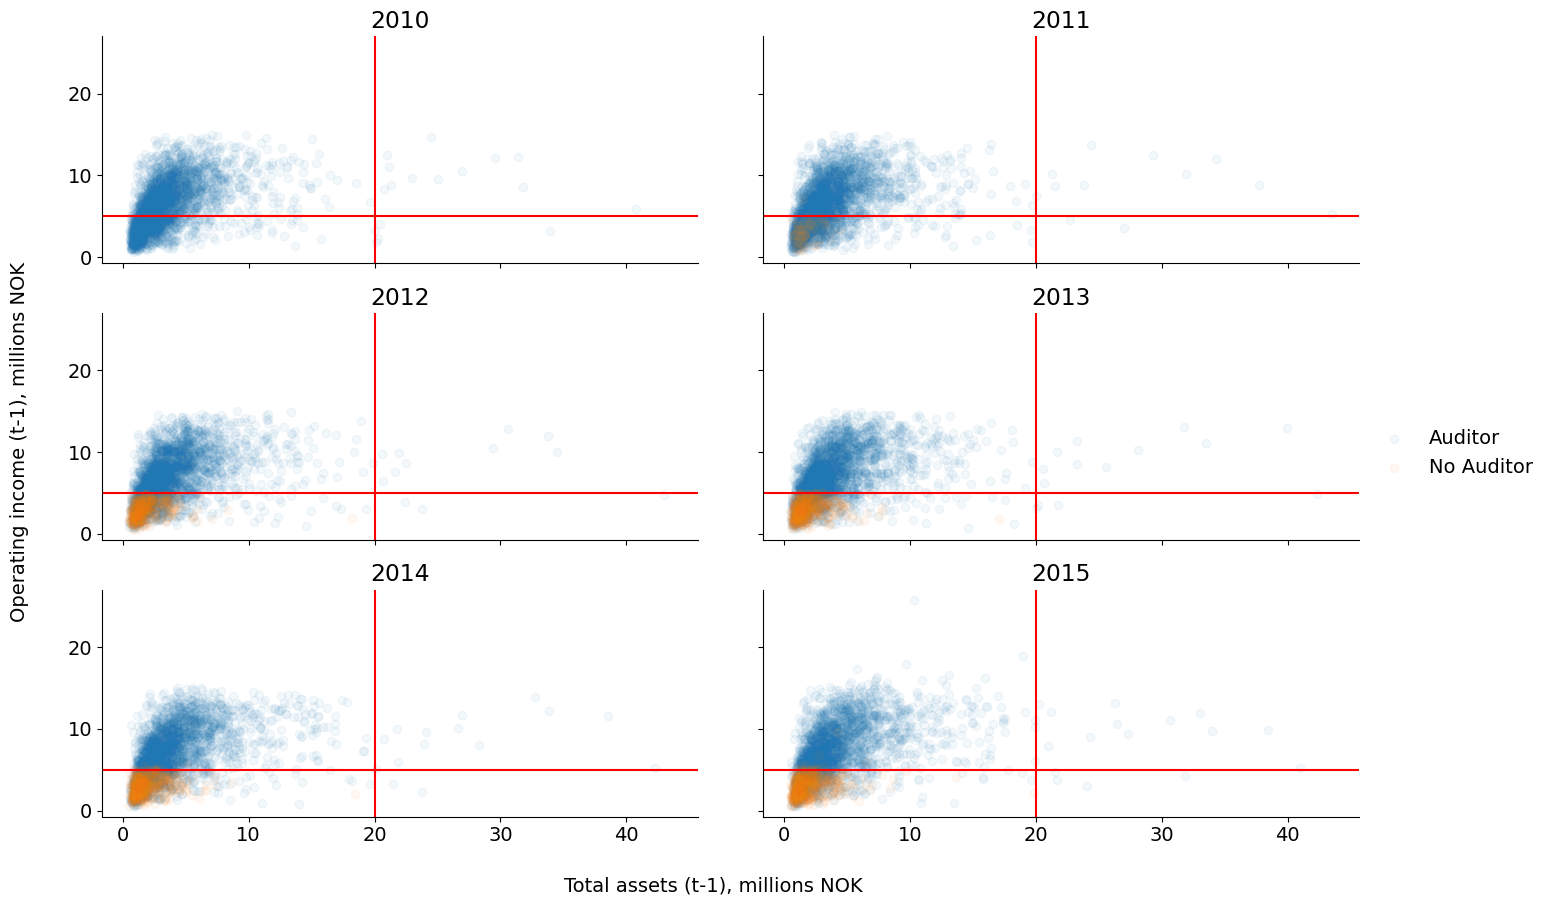

In [66]:
# Visualize the incidence of firms that have forgone an audit after 2010
year_lab = [str(2010 + i) for i in range(6)]

aq_long['Eiendeler_lagM'] = aq_long['Eiendeler_lag'] / 1000000
aq_long['driftsinntekter_labM'] = aq_long['driftsinntekter_lag'] / 1000000

aud_scatter = sns.FacetGrid(aq_long[(aq_long['year'] > 2009)], col = 'year', hue = 'no_auditor_lab', col_wrap = 2, legend_out = True)
aud_scatter = (aud_scatter.map(plt.scatter, 'Eiendeler_lagM', 'driftsinntekter_labM', alpha = .05).set_axis_labels('', ''))

aud_scatter.fig.set_size_inches([15, 9])
aud_scatter.add_legend()
aud_scatter._legend.set_title('')

for ax in aud_scatter.axes:
    ax.axvline(20, color = 'red')
    ax.axhline(5, color = 'red')

for i, ax in enumerate(aud_scatter.axes):
    ax.set_title(year_lab[i])

aud_scatter.fig.text(.5, 0, 'Total assets (t-1), millions NOK', ha = 'center')
aud_scatter.fig.text(.08, .5, 'Operating income (t-1), millions NOK', va = 'center', rotation = 'vertical')
plt.show()

The red lines are the thresholds, if a company has assets worth less than 20 mill and income less than 5 mill, they do not need to obtain an audit. The income threshold seems to be the constraining value for whether a firm is eligable to forgo and audit, there are few firms that are under the income threshold, but over the assets threshold. I will therefore focus on this threshold. 

##### Rescaling series

In [73]:
# Transforming the variables in the analysis to be standardized (subtract the mean and divide by the standard deviation), function for standardizing:
def rescale_series(ser):
    ser_rs = (ser - ser.mean()) / ser.std()
    return ser_rs

In [74]:
# Transform all continuous variables:
transformes_vars = ['AM', 'EK', 'Varelager', 'OM', 'KF', 'LG', 'KG', 'Varekost', 'Netincome', 'Avskrivninger', 'ordres', 'rentekostnad', 'Driftsresultat', 'Varigedm', 'age', 'cash', 'Finam', 'konsernbidrag', 'utbytte', 'rentekost_foretak', 'annen_finanskost','Eiendeler', 'ROA', 'driftsinntekter_lag', 'Eiendeler_lag', 'antall_ansatte', 'leverage', 'endring_Eiendeler', 'risk_roa', 'cash_flow', 'cash_flow_mu', 'cash_flow_sd']

In [75]:
# Limit data to 2011 to 2015:
aq_rs = aq_long.loc[aq_long['year'] > 2010, :].copy()

In [76]:
# Saving some standard deviations and mean for later use:
operIncome_std = aq_rs['driftsinntekter'].std()
dividend_std = aq_rs['utbytte'].std()
dividend_mu = aq_rs['utbytte'].mean()

In [77]:
# Rescale variables:
aq_rs.loc[:, transformes_vars] = aq_rs.loc[:, transformes_vars].apply(rescale_series)

In [78]:
# Rescale driftsinntekter
aq_rs.loc[:, 'driftsinntekter'] = (aq_rs['driftsinntekter'] - 5000000) / operIncome_std

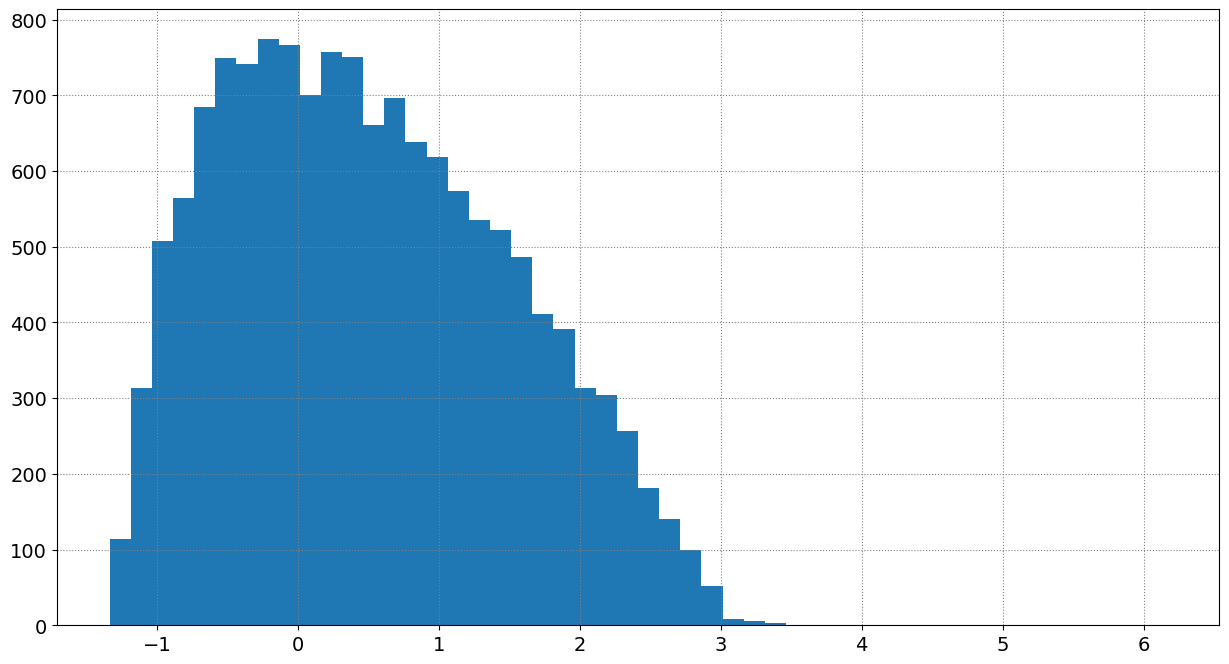

In [79]:
aq_rs['driftsinntekter'].hist(bins = 50)
plt.show()

##### Naive model

In [80]:
# Running a simple naive regression model, with the dividend on the no_auditor indicator variables and year as indicator variables using the C() operator (categorical):
rd_mod1 = smf.ols('utbytte ~ no_auditor + C(year)', data = aq_rs).fit()
rd_mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     25.68
Date:                Thu, 07 Dec 2023   Prob (F-statistic):           6.76e-26
Time:                        13:34:29   Log-Likelihood:                -20269.
No. Observations:               14330   AIC:                         4.055e+04
Df Residuals:                   14324   BIC:                         4.060e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0199      0.019     -1.071      0.284      -0.056       0.017
C(year)[T.2012]     0.0587      0.026      2.218      0.027       0.007       0.110
C(year)[T.2013]     0.0742      0.027      2.799      0.005       0.022       0.126
C(year)[T.2014]     0.0740      0.027      2.787      0.005       0.022       0.126
C(year)[T.2015]     0.0814      0.027      3.063      0.002       0.029       0.134
no_auditor         -0.2745      0.025    -11.204      0.000      -0.323      -0.226
==============================================================================
Omnibus:                    17008.853   Durbin-Watson:                   1.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3192772.769
Skew:                           6.160   Prob(JB):                         0.00
Kurtosis:                      75.080   Cond. No.                         5.96
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Lurking variables and omitted variable bias

In [81]:
# Creating a second model where I control for operating income, as well as other confounding variables that may be correlated with both the indicator variable no_auditor and the dividend. Including number of employees and total assets, as well as firm risk and firm leverage:
regFormula = 'utbytte ~ no_auditor + C(year) + driftsinntekter + driftsinntekter ** 2 + antall_ansatte + Eiendeler + risk_roa + leverage'
rs_mod2 = smf.ols(regFormula, data = aq_rs).fit()
rs_mod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     122.8
Date:                Thu, 07 Dec 2023   Prob (F-statistic):          6.83e-247
Time:                        13:54:26   Log-Likelihood:                -19743.
No. Observations:               14330   AIC:                         3.951e+04
Df Residuals:                   14319   BIC:                         3.959e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1317      0.019     -7.040      0.000      -0.168      -0.095
C(year)[T.2012]     0.0135      0.026      0.529      0.597      -0.037       0.064
C(year)[T.2013]     0.0191      0.026      0.745      0.456      -0.031       0.069
C(year)[T.2014]     0.0022      0.026      0.085      0.933      -0.048       0.053
C(year)[T.2015]    -0.0028      0.026     -0.109      0.913      -0.053       0.048
no_auditor          0.0722      0.027      2.720      0.007       0.020       0.124
driftsinntekter     0.2260      0.011     21.469      0.000       0.205       0.247
antall_ansatte     -0.0882      0.009    -10.075      0.000      -0.105      -0.071
Eiendeler           0.1287      0.010     13.305      0.000       0.110       0.148
risk_roa           -0.0232      0.009     -2.670      0.008      -0.040      -0.006
leverage            0.0792      0.009      8.739      0.000       0.061       0.097
==============================================================================
Omnibus:                    16751.549   Durbin-Watson:                   1.094
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3323873.499
Skew:                           5.959   Prob(JB):                         0.00
Kurtosis:                      76.653   Cond. No.                         7.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Post-treatment variables

In [82]:
# Including cash-flow in the model:
regFormula = 'utbytte ~ no_auditor + C(year) + driftsinntekter + driftsinntekter ** 2 + antall_ansatte + Eiendeler + risk_roa + leverage + cash_flow_mu + cash_flow_sd'
rs_mod3 = smf.ols(regFormula, data = aq_rs).fit()
rs_mod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     541.1
Date:                Thu, 07 Dec 2023   Prob (F-statistic):               0.00
Time:                        14:01:30   Log-Likelihood:                -17653.
No. Observations:               14330   AIC:                         3.533e+04
Df Residuals:                   14317   BIC:                         3.543e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.0578      0.016     -3.569      0.000      -0.090      -0.026
C(year)[T.2012]     0.0236      0.022      1.068      0.286      -0.020       0.067
C(year)[T.2013]     0.0311      0.022      1.406      0.160      -0.012       0.075
C(year)[T.2014]     0.0248      0.022      1.117      0.264      -0.019       0.068
C(year)[T.2015]     0.0270      0.022      1.212      0.225      -0.017       0.071
no_auditor          0.0517      0.023      2.252      0.024       0.007       0.097
driftsinntekter     0.0576      0.010      6.055      0.000       0.039       0.076
antall_ansatte      0.0172      0.008      2.228      0.026       0.002       0.032
Eiendeler           0.0017      0.009      0.183      0.855      -0.016       0.019
risk_roa           -0.0461      0.009     -5.278      0.000      -0.063      -0.029
leverage            0.1023      0.008     12.966      0.000       0.087       0.118
cash_flow_mu        0.5182      0.008     67.821      0.000       0.503       0.533
cash_flow_sd        0.0606      0.009      6.727      0.000       0.043       0.078
==============================================================================
Omnibus:                    16501.229   Durbin-Watson:                   1.357
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          5041003.611
Skew:                           5.612   Prob(JB):                         0.00
Kurtosis:                      94.196   Cond. No.                         8.46
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Sub-classification

In [85]:
regFormula = 'utbytte ~ no_auditor + C(year) + driftsinntekter + driftsinntekter ** 2 + antall_ansatte + Eiendeler + leverage + risk_roa + cash_flow_mu + cash_flow_sd'
rs_mod4 = smf.ols(regFormula, data = aq_rs.loc[aq_rs['choseAudit'] == 0, :]).fit()
rs_mod4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     449.5
Date:                Thu, 07 Dec 2023   Prob (F-statistic):               0.00
Time:                        14:18:02   Log-Likelihood:                -14476.
No. Observations:               11110   AIC:                         2.898e+04
Df Residuals:                   11097   BIC:                         2.907e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1456      0.024     -6.074      0.000      -0.193      -0.099
C(year)[T.2012]     0.0378      0.028      1.346      0.178      -0.017       0.093
C(year)[T.2013]     0.0544      0.028      1.950      0.051      -0.000       0.109
C(year)[T.2014]     0.0509      0.028      1.821      0.069      -0.004       0.106
C(year)[T.2015]     0.0519      0.028      1.860      0.063      -0.003       0.107
no_auditor          0.1537      0.030      5.077      0.000       0.094       0.213
driftsinntekter     0.0986      0.013      7.348      0.000       0.072       0.125
antall_ansatte      0.0225      0.009      2.579      0.010       0.005       0.040
Eiendeler          -0.0145      0.011     -1.330      0.183      -0.036       0.007
leverage            0.1403      0.011     13.257      0.000       0.120       0.161
risk_roa           -0.0830      0.013     -6.207      0.000      -0.109      -0.057
cash_flow_mu        0.5371      0.009     62.619      0.000       0.520       0.554
cash_flow_sd        0.0792      0.011      7.236      0.000       0.058       0.101
==============================================================================
Omnibus:                    12249.409   Durbin-Watson:                   1.348
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3188696.954
Skew:                           5.217   Prob(JB):                         0.00
Kurtosis:                      85.337   Cond. No.                         9.90
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

##### Industry fixed-effects

In [86]:
regFormula = 'utbytte ~ C(nkode_agg) + no_auditor + C(year) + driftsinntekter + driftsinntekter ** 2 + antall_ansatte + Eiendeler + risk_roa + leverage  + cash_flow_mu + cash_flow_sd'
rs_mod5 = smf.ols(regFormula, data = aq_rs.loc[aq_rs['choseAudit'] == 0, :]).fit()
rs_mod5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.339
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     83.15
Date:                Thu, 07 Dec 2023   Prob (F-statistic):               0.00
Time:                        14:20:35   Log-Likelihood:                -14379.
No. Observations:               11110   AIC:                         2.890e+04
Df Residuals:                   11041   BIC:                         2.940e+04
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.3385      0.109     -3.108      0.002      -0.552      -0.125
C(nkode_agg)[T.2]      0.4998      0.247      2.020      0.043       0.015       0.985
C(nkode_agg)[T.8]      0.1144      0.149      0.766      0.444      -0.178       0.407
C(nkode_agg)[T.10]     0.2489      0.130      1.908      0.056      -0.007       0.505
C(nkode_agg)[T.11]     0.0392      0.456      0.086      0.931      -0.854       0.933
C(nkode_agg)[T.13]     0.1375      0.142      0.966      0.334      -0.141       0.416
C(nkode_agg)[T.14]     0.3256      0.300      1.086      0.278      -0.262       0.914
C(nkode_agg)[T.15]     0.1142      0.410      0.278      0.781      -0.690       0.919
C(nkode_agg)[T.16]     0.1160      0.124      0.936      0.349      -0.127       0.359
C(nkode_agg)[T.17]     0.3187      0.260      1.224      0.221      -0.191       0.829
C(nkode_agg)[T.18]     0.2752      0.121      2.279      0.023       0.038       0.512
C(nkode_agg)[T.20]     0.1419      0.196      0.723      0.470      -0.243       0.526
C(nkode_agg)[T.22]     0.2399      0.138      1.735      0.083      -0.031       0.511
C(nkode_agg)[T.23]     0.4545      0.129      3.515      0.000       0.201       0.708
C(nkode_agg)[T.24]     0.2799      0.277      1.010      0.312      -0.263       0.823
C(nkode_agg)[T.25]     0.2908      0.118      2.475      0.013       0.060       0.521
C(nkode_agg)[T.26]     0.2191      0.202      1.087      0.277      -0.176       0.614
C(nkode_agg)[T.27]     0.1544      0.171      0.901      0.367      -0.181       0.490
C(nkode_agg)[T.28]     0.3713      0.127      2.918      0.004       0.122       0.621
C(nkode_agg)[T.29]     0.0920      0.300      0.307      0.759      -0.496       0.680
C(nkode_agg)[T.30]     0.0492      0.252      0.195      0.846      -0.446       0.544
C(nkode_agg)[T.31]     0.3125      0.147      2.132      0.033       0.025       0.600
C(nkode_agg)[T.32]     0.3042      0.136      2.234      0.026       0.037       0.571
C(nkode_agg)[T.33]     0.2974      0.126      2.366      0.018       0.051       0.544
C(nkode_agg)[T.41]     0.1229      0.128      0.964      0.335      -0.127       0.373
C(nkode_agg)[T.42]     0.3049      0.179      1.704      0.088      -0.046       0.656
C(nkode_agg)[T.43]     0.2483      0.109      2.278      0.023       0.035       0.462
C(nkode_agg)[T.45]     0.1918      0.111      1.732      0.083      -0.025       0.409
C(nkode_agg)[T.46]     0.0916      0.109      0.840      0.401      -0.122       0.306
C(nkode_agg)[T.47]     0.1320      0.108      1.222      0.222      -0.080       0.344
C(nkode_agg)[T.49]     0.3229      0.143      2.265      0.024       0.043       0.602
C(nkode_agg)[T.50]    -0.8718      0.304     -2.866      0.004      -1.468      -0.276
C(nkode_agg)[T.52]    -0.0817      0.2

##### Regression Discontinuity.

In [88]:
# Limit data to firms within +/- 1 mill in operating income:
min_di = (4e6 - 5e6) / operIncome_std
max_di = (6e6 - 5e6) / operIncome_std
print(min_di, max_di)

aq_narrow = aq_rs.loc[((aq_rs['choseAudit'] == 0) & (aq_rs['driftsinntekter'] > min_di) & (aq_rs['driftsinntekter'] < max_di)), :]

-0.29708467138569616 0.29708467138569616


In [89]:
regFormula = 'utbytte ~ no_auditor + C(year) + driftsinntekter + driftsinntekter ** 2 + antall_ansatte + Eiendeler + risk_roa + leverage + cash_flow_mu + cash_flow_sd + C(nkode_agg)'
rs_mod6 = smf.ols(regFormula, data = aq_narrow).fit()
rs_mod6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     8.309
Date:                Thu, 07 Dec 2023   Prob (F-statistic):           8.74e-59
Time:                        14:30:15   Log-Likelihood:                -1765.4
No. Observations:                1837   AIC:                             3649.
Df Residuals:                    1778   BIC:                             3974.
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.4391      0.325     -1.352      0.177      -1.076       0.198
C(year)[T.2012]    -2.423e-05      0.050     -0.000      1.000      -0.098       0.098
C(year)[T.2013]        0.0043      0.049      0.088      0.930      -0.092       0.101
C(year)[T.2014]       -0.0378      0.050     -0.750      0.453      -0.137       0.061
C(year)[T.2015]        0.0612      0.050      1.211      0.226      -0.038       0.160
C(nkode_agg)[T.2]     -0.0836      0.732     -0.114      0.909      -1.519       1.351
C(nkode_agg)[T.8]      0.1775      0.435      0.408      0.683      -0.675       1.030
C(nkode_agg)[T.10]     0.0700      0.383      0.183      0.855      -0.682       0.822
C(nkode_agg)[T.13]     0.3290      0.350      0.941      0.347      -0.357       1.015
C(nkode_agg)[T.14]     0.2259      0.560      0.404      0.687      -0.872       1.324
C(nkode_agg)[T.15]     0.2159      0.433      0.499      0.618      -0.633       1.065
C(nkode_agg)[T.16]     0.2391      0.344      0.694      0.488      -0.436       0.914
C(nkode_agg)[T.18]     0.4581      0.336      1.363      0.173      -0.201       1.117
C(nkode_agg)[T.20]     0.0419      0.721      0.058      0.954      -1.372       1.456
C(nkode_agg)[T.22]     0.4945      0.376      1.313      0.189      -0.244       1.233
C(nkode_agg)[T.23]     0.3601      0.364      0.990      0.322      -0.353       1.073
C(nkode_agg)[T.24]     1.0495      0.560      1.874      0.061      -0.049       2.148
C(nkode_agg)[T.25]     0.5668      0.332      1.705      0.088      -0.085       1.219
C(nkode_agg)[T.26]     0.2231      0.417      0.535      0.593      -0.595       1.042
C(nkode_agg)[T.27]     0.2203      0.416      0.529      0.597      -0.596       1.037
C(nkode_agg)[T.28]     0.4150      0.349      1.190      0.234      -0.269       1.099
C(nkode_agg)[T.30]     0.2191      0.492      0.445      0.656      -0.746       1.184
C(nkode_agg)[T.31]     0.3741      0.358      1.044      0.297      -0.329       1.077
C(nkode_agg)[T.32]     0.4098      0.351      1.166      0.244      -0.280       1.099
C(nkode_agg)[T.33]     0.2554      0.345      0.739      0.460      -0.422       0.933
C(nkode_agg)[T.41]     0.3289      0.348      0.945      0.345      -0.353       1.011
C(nkode_agg)[T.42]     0.4427      0.397      1.116      0.264      -0.335       1.220
C(nkode_agg)[T.43]     0.3270      0.325      1.007      0.314      -0.310       0.964
C(nkode_agg)[T.45]     0.3199      0.326      0.980      0.327      -0.320       0.960
C(nkode_agg)[T.46]     0.2897      0.325      0.891      0.373      -0.348       0.928
C(nkode_agg)[T.47]     0.2991      0.324      0.923      0.356      -0.336       0.935
C(nkode_agg)[T.49]     0.4610      0.364      1.266      0.206      -0.253       1.175
C(nkode_agg)[T.52]     0.3147      0.4

##### Illustration of regression discontinuity

In [90]:
def regSim(regMod): 
    #extract values from regression model
    nmk = regMod.df_resid #n-k
    sigma_hat = np.sqrt(regMod.mse_resid)
    bs_vcov = regMod.cov_params(scale = 1)
    bs = regMod.params
    
    #create simulated values
    sigma_sim = sigma_hat * np.sqrt(nmk / np.random.chisquare(nmk, 1))
    V_sim = np.array(bs_vcov) * sigma_sim ** 2
    bs_sim = np.random.multivariate_normal(bs, V_sim, 1)
    
    return bs_sim.flatten(), sigma_sim

In [91]:
# Running a model without industry fixed effects for simplicity:
regFormula = 'utbytte ~ no_auditor + C(year) + driftsinntekter + driftsinntekter ** 2 + antall_ansatte + Eiendeler + risk_roa + leverage + cash_flow_mu + cash_flow_sd'
rs_mod_fig = smf.ols(regFormula, data = aq_narrow).fit()
rs_mod_fig.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                utbytte   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.182
Method:                 Least Squares   F-statistic:                     34.96
Date:                Thu, 07 Dec 2023   Prob (F-statistic):           1.27e-73
Time:                        14:34:31   Log-Likelihood:                -1795.5
No. Observations:                1837   AIC:                             3617.
Df Residuals:                    1824   BIC:                             3689.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.1000      0.038     -2.621      0.009      -0.175      -0.025
C(year)[T.2012]     0.0024      0.050      0.049      0.961      -0.095       0.100
C(year)[T.2013]    -0.0011      0.049     -0.021      0.983      -0.097       0.095
C(year)[T.2014]    -0.0408      0.050     -0.815      0.415      -0.139       0.057
C(year)[T.2015]     0.0641      0.050      1.274      0.203      -0.035       0.163
no_auditor          0.1396      0.045      3.080      0.002       0.051       0.228
driftsinntekter     0.2575      0.108      2.379      0.017       0.045       0.470
antall_ansatte     -0.0219      0.022     -0.994      0.320      -0.065       0.021
Eiendeler           0.0746      0.019      3.909      0.000       0.037       0.112
risk_roa           -0.0042      0.023     -0.181      0.856      -0.050       0.041
leverage            0.0321      0.012      2.649      0.008       0.008       0.056
cash_flow_mu        0.4086      0.022     18.357      0.000       0.365       0.452
cash_flow_sd       -0.0025      0.020     -0.125      0.901      -0.042       0.037
==============================================================================
Omnibus:                     2992.007   Durbin-Watson:                   1.828
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          2992577.853
Skew:                          10.204   Prob(JB):                         0.00
Kurtosis:                     199.674   Cond. No.                         11.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [115]:
bs_sim, sigma_sim = regSim(rs_mod_fig)
sim_inter = bs_sim[0]
sim_treat = bs_sim[5]
sim_beta = bs_sim[6]
print(sim_inter, sim_treat, sim_beta)

-0.11438194985213682 0.06714465767313715 0.18082232375858753


In [119]:
se = np.sqrt(np.diagonal(rs_mod_fig.cov_params()))
params = rs_mod_fig.params
ses = dict(zip(params.index, se))

treat = params['no_auditor']
treat_se = ses['no_auditor']
inter = params['Intercept']
inter_se = ses['Intercept']
di = params['driftsinntekter']
di_se = ses['driftsinntekter']

print('Treatment:\t', treat, '\t', treat_se)
print('Intercept:\t', inter, '\t', inter_se)
print('Driftsinnt:\t', di, '\t', di_se)

Treatment:	 0.13958126433061244 	 0.04531536307535887
Intercept:	 -0.09995932575667374 	 0.03814291312125961
Driftsinnt:	 0.2575032335421981 	 0.10823193503332618


In [120]:
pre_x = np.linspace(-2, 0, 1000)
post_x = np.linspace(0, 2, 1000)

pre_y = inter + pre_x * di + treat
post_y = inter + post_x * di

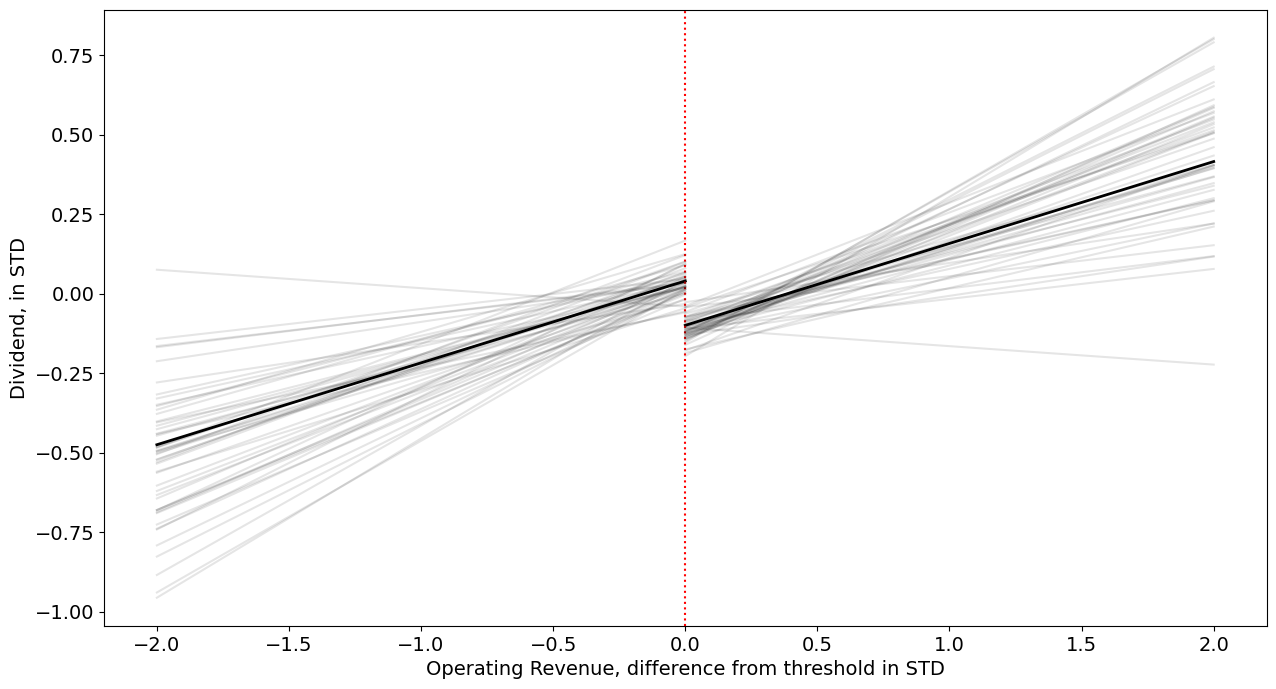

In [122]:
fig, ax = plt.subplots()
ax.plot(pre_x, pre_y, 'k-', lw = 2)
ax.plot(post_x, post_y, 'k-', lw = 2)
ax.axvline(0, color = 'red', linestyle = ':')

# Uncertainty
for i in range(50):
    bs_sim, sigma_sim = regSim(rs_mod_fig)
    sim_inter = bs_sim[0]
    sim_treat = bs_sim[5]
    sim_beta = bs_sim[6]

    pre_y_r = sim_inter + sim_beta * pre_x + sim_treat
    post_y_r = sim_inter + sim_beta * post_x

    ax.plot(pre_x, pre_y_r, 'k-', alpha = .1)
    ax.plot(post_x, post_y_r, 'k-', alpha = .1)

ax.set_xlabel('Operating Revenue, difference from threshold in STD')
ax.set_ylabel('Dividend, in STD')
plt.show()

##### Matching

Two basic steps:
- Some form of algorithm is used to find an appropriate, balanced control group for the treatment group.
- Run a new regression with the treatment and new matched control group.

In [123]:
# Propensity Score Matching:
# Creating logistic regression model of what firms are likely to forgo auditing among firms below the threshold. The fitted values (as probabilities) are called propensity scores:
ps_fit = smf.logit()

TypeError: Model.from_formula() missing 2 required positional arguments: 'formula' and 'data'

##### Matching algorithm